In [ ]:
import polars as pl
import utils
from run_capsule import sessions_with_good_fold_coverage

In [2]:
DATACUBE_VERSION = 'v0.0.289'

In [10]:
class Params:
    good_block_dprime_threshold = 1.0
    good_block_min_contingent_rewards = 10

params = Params()

In [26]:
trials = pl.read_parquet(f'/root/capsule/data/dynamicrouting_datacube_{DATACUBE_VERSION}/consolidated/trials.parquet')
    
session_table = pl.read_parquet(f'/root/capsule/data/dynamicrouting_datacube_{DATACUBE_VERSION}/session_table.parquet')
good_behavior_sessions = session_table.filter(pl.col('is_good_behavior'))['session_id'].to_list()
sessions_to_analyze = (
    utils.get_df('session')
    .filter(
        #pl.col('keywords').list.contains('production'),
        ~pl.col('keywords').list.contains('templeton'),
        ~pl.col('keywords').list.contains('injection_perturbation'),
        ~pl.col('keywords').list.contains('injection_control'),
        ~pl.col('keywords').list.contains('opto_perturbation'),
        ~pl.col('keywords').list.contains('opto_control'),
        ~pl.col('keywords').list.contains('issues'),
        ~pl.col('keywords').list.contains('naive'),
        ~pl.col('keywords').list.contains('context_naive'),
        pl.col('session_id').is_in(good_behavior_sessions),
    )
)
trials = trials.filter(pl.col('session_id').is_in(sessions_to_analyze['session_id'].implode()))

n_sessions_before_block_filter = trials['session_id'].n_unique()
eligible_sessions = sessions_with_good_fold_coverage(
    trials, utils.get_df('performance'), params
)
trials = trials.filter(pl.col('session_id').is_in(eligible_sessions))

In [27]:
trials

start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct,session_idx,date,subject_id,session_id,id,opto_start_time,opto_stop_time,opto_wavelength,opto_location_bregma_x,opto_location_bregma_y,opto_duration,opto_label,opto_power,opto_stim_name,is_single_opto_location
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,i64,str,i64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i64,date,i64,str,i64,f64,f64,f64,f64,f64,f64,str,f64,str,bool
85.7625,91.26691,85.7625,87.2302,87.29094,87.79137,87.34692,88.26434,87.98116,87.97838,87.3636,88.29178,91.29429,"""vis1""",0.0,0,"""vis""",0,0.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",0,null,null,null,null,null,null,null,null,null,null
91.93403,97.43867,91.93403,93.40193,93.46277,93.96319,93.51867,94.43624,94.10252,94.09598,93.53536,94.4636,97.4661,"""vis1""",0.0,0,"""vis""",1,1.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",1,null,null,null,null,null,null,null,null,null,null
98.5062,104.01127,98.5062,99.9741,100.03491,100.53533,100.09095,101.00829,100.34111,100.34042,100.10758,101.03576,104.03827,"""vis1""",0.0,0,"""vis""",2,2.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",2,null,null,null,null,null,null,null,null,null,null
105.22842,110.73305,105.22842,106.69634,106.7572,107.25762,106.81309,107.73057,107.03017,107.02306,106.82981,107.75805,110.760545,"""vis1""",0.5,0,"""vis""",3,3.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",3,null,null,null,null,null,null,null,null,null,null
111.78396,117.28853,111.78396,113.25187,113.31269,113.8131,113.36861,114.28608,113.56879,113.56762,113.38531,114.31351,117.31604,"""vis1""",0.5,0,"""vis""",4,4.0,0.0,true,true,false,true,false,false,false,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false,0,2022-08-15,626791,"""626791_2022-08-15""",4,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5747.15466,5752.69262,5747.15466,5748.6393,5748.700211,5749.200621,5748.75603,5749.67346,null,null,null,5749.701041,5752.720241,"""vis2""",0.5,5,"""aud""",537,83.0,0.0,false,true,false,false,false,true,false,false,true,false,false,false,false,false,false,true,false,false,false,false,true,false,true,false,true,false,false,false,false,0,2025-10-22,805752,"""805752_2025-10-22""",537,null,null,null,null,null,null,null,null,null,null
5753.96037,5759.48173,5753.96037,5755.42823,5755.4694,5755.9694,5755.54503,5756.46248,5755.89533

In [25]:
s = utils.get_df('session')

'production' in s.select('keywords').explode('keywords')

/tmp/ipykernel_961/2443068718.py:3: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  'production' in s.select('keywords').explode('keywords')


False

## ANALYSIS

In [1]:
import json
import polars as pl
from upath import UPath
import numpy as np
from matplotlib import pyplot as plt

In [2]:
s3_uri = "s3://aind-scratch-data/dynamic-routing/neural_trajectory_separation_all_conditions"

In [3]:

run_name = "crossval_082126"
# This bucket is public, so explicitly use unsigned (anonymous) S3 requests.
s3_root = UPath(s3_uri, anon=True)

# Parameters are stored beside (rather than inside) the run directory.
trajectory_params = json.loads((s3_root / f"{run_name}.json").read_text())

# Results are one parquet per area/condition-pair in the run subdirectory.
run_dir = s3_root / run_name
available_parquet_paths = sorted(run_dir.glob("*.parquet"))

# Set this to a list of filenames (e.g. ["MOs_0.parquet", "MOs_1.parquet"])
# to load only selected results. Leave as None to load every parquet in the run.
parquet_filenames = None
parquet_paths = (
    available_parquet_paths
    if parquet_filenames is None
    else [run_dir / filename for filename in parquet_filenames]
)

# Give Polars S3FS file handles so it uses the same anonymous connection.
trajectory_results = {}
for path in parquet_paths:
    with path.open("rb") as parquet_file:
        trajectory_results[path.stem] = pl.read_parquet(parquet_file)

print(f"Loaded parameters and {len(trajectory_results)} parquet file(s).")
print("Available parquet files:", [path.name for path in available_parquet_paths])
trajectory_params


Loaded parameters and 990 parquet file(s).
Available parquet files: ['ACAd_0.parquet', 'ACAd_1.parquet', 'ACAd_10.parquet', 'ACAd_11.parquet', 'ACAd_12.parquet', 'ACAd_13.parquet', 'ACAd_14.parquet', 'ACAd_2.parquet', 'ACAd_3.parquet', 'ACAd_4.parquet', 'ACAd_5.parquet', 'ACAd_6.parquet', 'ACAd_7.parquet', 'ACAd_8.parquet', 'ACAd_9.parquet', 'ACAv_0.parquet', 'ACAv_1.parquet', 'ACAv_10.parquet', 'ACAv_11.parquet', 'ACAv_12.parquet', 'ACAv_13.parquet', 'ACAv_14.parquet', 'ACAv_2.parquet', 'ACAv_3.parquet', 'ACAv_4.parquet', 'ACAv_5.parquet', 'ACAv_6.parquet', 'ACAv_7.parquet', 'ACAv_8.parquet', 'ACAv_9.parquet', 'AId_0.parquet', 'AId_1.parquet', 'AId_10.parquet', 'AId_11.parquet', 'AId_12.parquet', 'AId_13.parquet', 'AId_14.parquet', 'AId_2.parquet', 'AId_3.parquet', 'AId_4.parquet', 'AId_5.parquet', 'AId_6.parquet', 'AId_7.parquet', 'AId_8.parquet', 'AId_9.parquet', 'AIp_0.parquet', 'AIp_1.parquet', 'AIp_10.parquet', 'AIp_11.parquet', 'AIp_12.parquet', 'AIp_13.parquet', 'AIp_14.parquet

{'intervals_table': 'trials',
 'align_to_col': 'stim_start_time',
 'pre': 0.5,
 'post': 0.5,
 'default_qc_only': True,
 'as_spike_count': False,
 'as_binarized_array': True,
 'bin_size_s': 0.001,
 'datacube_version': 'v0.0.289',
 'spike_col': 'binarized_spike_times',
 'input_dir_name': '2026-08-20',
 'conv_kernel_s': 0.01,
 'decoder_areas_to_average': ['ACAd',
  'AId',
  'AIp',
  'CP',
  'FRP',
  'ILA',
  'MOp',
  'MOs',
  'MRN',
  'ORBl',
  'ORBvl',
  'PL',
  'SCm',
  'SSp',
  'SSs'],
 'baseline_start_s': -0.5,
 'baseline_end_s': -0.01,
 'projection_stimulus_start_s': 0.0,
 'projection_stimulus_end_s': 0.1,
 'good_block_dprime_threshold': 1.0,
 'good_block_min_contingent_rewards': 10,
 'integer_id_to_condition_mapping': {'0': [['is_aud_target',
    'is_aud_rewarded',
    'is_hit'],
   ['is_aud_target', 'is_vis_rewarded', 'is_correct_reject']],
  '1': [['is_aud_target', 'is_aud_rewarded', 'is_hit'],
   ['is_aud_target', 'is_vis_rewarded', 'is_false_alarm']],
  '2': [['is_aud_target',
 

In [4]:
mapping = trajectory_params['integer_id_to_condition_mapping']

In [69]:
trajectory_results['ORBm_0']['baseline_separation'].hist()

breakpoint,category,count
f64,cat,u32
-1.070007,"""[-1.320841, -1.070007]""",1
-0.819172,"""(-1.070007, -0.819172]""",0
-0.568338,"""(-0.819172, -0.568338]""",0
-0.317503,"""(-0.568338, -0.317503]""",2
-0.066669,"""(-0.317503, -0.066669]""",1
0.184165,"""(-0.066669, 0.184165]""",0
0.435,"""(0.184165, 0.435]""",0
0.685834,"""(0.435, 0.685834]""",0
0.936669,"""(0.685834, 0.936669]""",1


In [75]:
mapping[str(condition)]

[['is_vis_target', 'is_vis_rewarded', 'is_hit'],
 ['is_vis_target', 'is_aud_rewarded', 'is_correct_reject']]

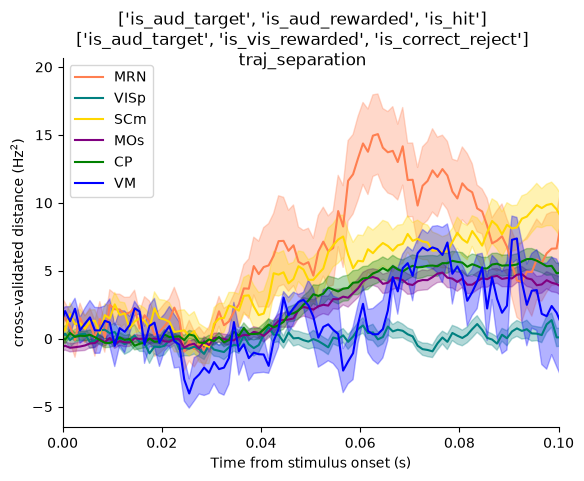

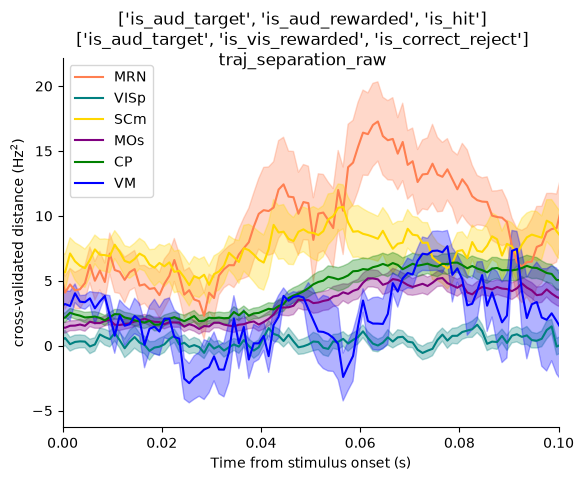

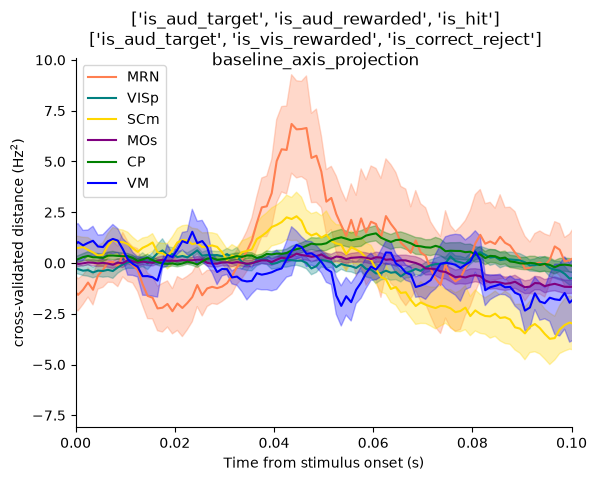

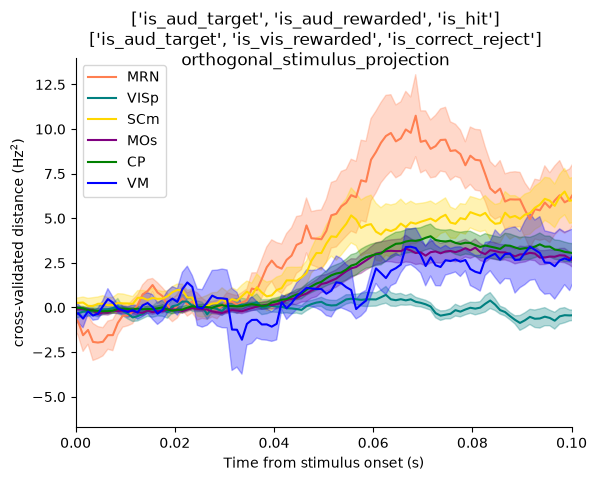

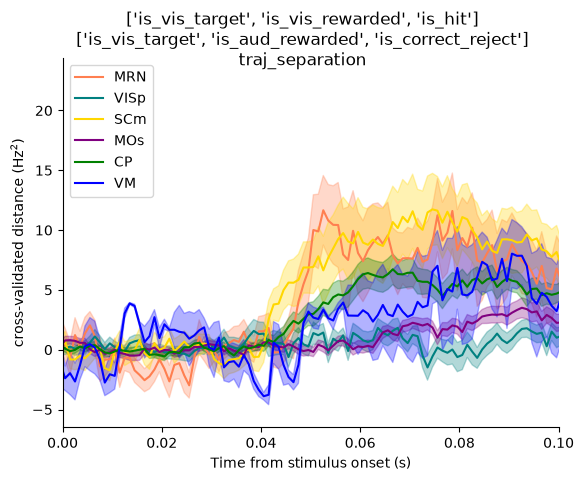

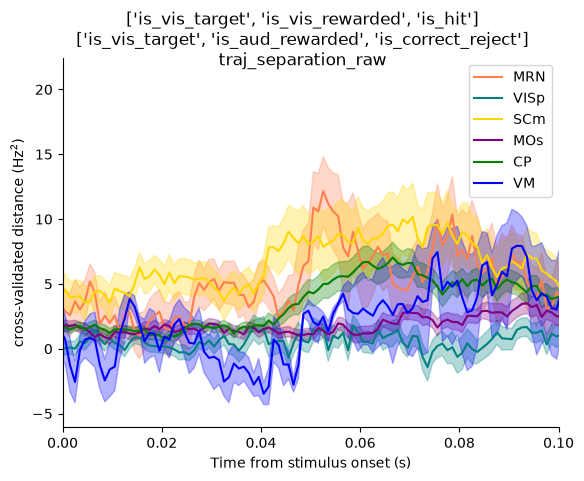

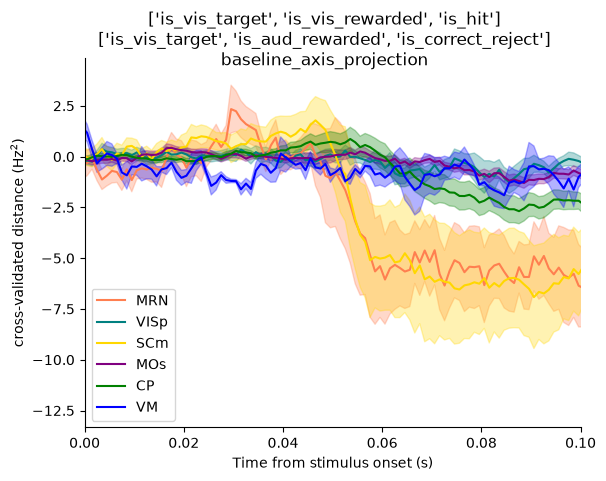

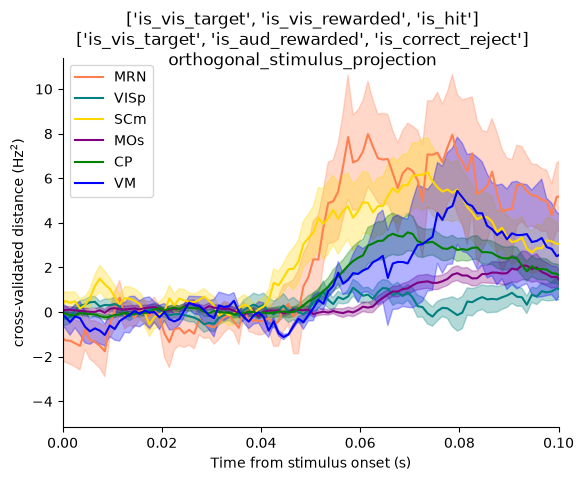

In [82]:
conditions_to_plot = [0,3]
show_sessions = False
regions = ['MRN', 'VISp', 'SCm', 'MOs', 'CP', 'VM']# 'MOs', 'CP', 'VM']
colors = {'MRN': 'coral',
          'VISp': 'teal',
          'SCm': 'gold',
          'MOs': 'purple',
          'CP': 'green',
          'VM': 'blue',
          #'MD': 'brown'
          }
time = np.linspace(-0.5, 0.5, 1000)
for condition in conditions_to_plot:

    for col in ['traj_separation', 'traj_separation_raw', 'baseline_axis_projection', 'orthogonal_stimulus_projection']:
        fig, ax = plt.subplots()
        fig.suptitle(f"{mapping[str(condition)][0]}\n{mapping[str(condition)][1]}\n{col}")
        for region in regions:
            results = np.stack(trajectory_results[f'{region}_{condition}'][col].to_numpy())
            if results.shape[0] > 0:
                mean_results = np.nanmean(results, axis=0)
                sem_results = np.nanstd(results, axis=0) / np.sqrt(results.shape[0])
                ax.plot(time, mean_results, label=region, color=colors[region])
                ax.fill_between(time, mean_results - sem_results, mean_results + sem_results, color=colors[region], alpha=0.3)
                ax.set_xlim([0,0.1])
                #also plot individual sessions in low alpha
                if show_sessions:
                    for session_result in results:
                        ax.plot(time, session_result, color=colors[region], alpha=0.1)
                ax.legend()
                #remove top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.set_xlabel('Time from stimulus onset (s)')
                ax.set_ylabel('cross-validated distance (Hz$^2$)')

In [6]:
BASELINE_SLICE = slice(400, 500)
STIMULUS_SLICE = slice(500, 600)
RESPONSE_SLICE = slice(900, 1000)

In [8]:
def _nanmean(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)) if not np.all(np.isnan(values)) else np.nan


def _session_window_mean(results, column, window):
    if results.height == 0:
        return np.nan

    vectors = np.stack(results[column].to_list())
    return _nanmean(vectors[:, window])


# Use only regions for which both requested condition files are available.
region_condition_keys = {
    condition: {
        key.rsplit('_', 1)[0]: key
        for key in trajectory_results
        if key.endswith(f'_{condition}')
    }
    for condition in (0, 3)
}
regions = sorted(set(region_condition_keys[0]) & set(region_condition_keys[3]))

window_specs = {
    'baseline': ('traj_separation_raw', BASELINE_SLICE),
    'stimulus': ('traj_separation', STIMULUS_SLICE),
    'response': ('traj_separation', RESPONSE_SLICE),
}

results = []
for region in regions:
    row = {'structure': region}
    for window_name, (column, window) in window_specs.items():
        for condition in (0, 3):
            key = region_condition_keys[condition][region]
            row[f'{window_name}_{condition}'] = _session_window_mean(
                trajectory_results[key], column, window
            )

        row[f'{window_name}_mean'] = _nanmean(
            [row[f'{window_name}_0'], row[f'{window_name}_3']]
        )
    results.append(row)

results_pd = pl.DataFrame(results)
results_pd

structure,baseline_0,baseline_3,baseline_mean,stimulus_0,stimulus_3,stimulus_mean,response_0,response_3,response_mean
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAd""",1.502729,1.389819,1.446274,1.453891,0.727255,1.090573,2.971338,3.919339,3.445338
"""ACAv""",0.533797,0.425162,0.47948,-0.082424,0.657399,0.287487,0.989634,1.6254,1.307517
"""AId""",1.52129,1.406537,1.463913,0.703495,0.70797,0.705732,8.189939,5.698412,6.944175
"""AIp""",-0.116185,0.297765,0.09079,0.502658,-0.431056,0.035801,0.151086,0.425799,0.288443
"""AON""",0.087611,0.113959,0.100785,0.492894,-0.024509,0.234192,2.187859,2.875097,2.531478
…,…,…,…,…,…,…,…,…,…
"""VISpm""",0.32994,0.391679,0.36081,0.287546,0.437062,0.362304,0.54606,1.052502,0.799281
"""VISpor""",0.651195,-0.533038,0.059078,-0.015381,0.167467,0.076043,1.202465,0.217998,0.710231
"""VM""",1.779941,0.331433,1.055687,1.621812,2.204114,1.912963,5.16462,4.479243,4.821932


In [9]:
results_pd['baseline_mean'].describe()

statistic,value
str,f64
"""count""",66.0
"""null_count""",0.0
"""mean""",0.647638
"""std""",0.854333
"""min""",-0.228065
"""25%""",0.148825
"""50%""",0.362351
"""75%""",0.967201
"""max""",4.880157


In [51]:
from importlib import reload
from dynamic_routing_analysis import ccf_utils
reload(ccf_utils)

<module 'dynamic_routing_analysis.ccf_utils' from '/Users/corbettb/Documents/GitHub/dynamic_routing_analysis/src/dynamic_routing_analysis/ccf_utils.py'>

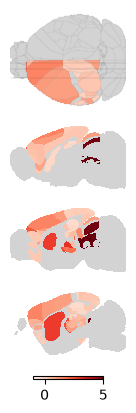

In [52]:
from dynamic_routing_analysis import plot_utils

regions=results_pd['structure']
values=results_pd['stimulus_mean']

chart,x = plot_utils.plot_brain_heatmap(
    regions=regions,
    values=values,
    sagittal_planes=np.array([-300,-1000,-2000,]) + ccf_utils.get_midline_ccf_ml(),
    #sagittal_planes=(-1000,-2000,),
    interactive=False,
    cmap='Reds',
    clevels=(-1,5),
)

In [46]:
ccf_utils.get_midline_ccf_ml()

5700.0

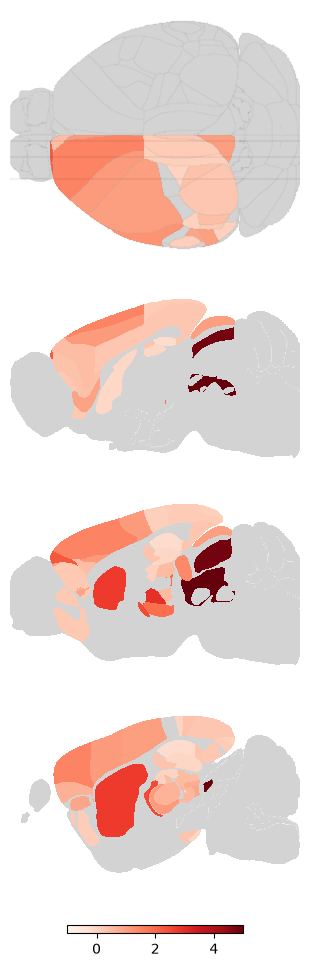

In [50]:
chart.set_size_inches(12,12)
chart